# Basic Statistics - 1

## Objective

The objective of this assignment is to perform descriptive statistical analysis on the sales dataset and understand the distribution and variation of the numerical variables. The analysis includes measures of central tendency and dispersion, along with appropriate visualizations such as histograms, boxplots, and bar charts. The final section summarizes the key findings and business insights obtained from the analysis.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [18]:
df = pd.read_csv("sales_data_with_discounts.csv")

df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.65,21153.50,160346.50
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.56,11676.10,89323.90
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.46,10657.91,102042.09
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.94,8364.07,112235.93
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,18.00,4372.95,19927.05


In [19]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 450
Number of columns: 13


In [20]:
# Display column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [21]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    str    
 1   Day                450 non-null    str    
 2   SKU                450 non-null    str    
 3   City               450 non-null    str    
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    str    
 6   Brand              450 non-null    str    
 7   Model              450 non-null    str    
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), str(7)
memory usage: 45.8 KB


## Descriptive Statistics

Descriptive statistics are used to summarize the central tendency, dispersion, and overall distribution of the numerical variables in the dataset.

In [22]:
# Descriptive statistics for numerical variables
descriptive_stats = df.describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Volume,450.00,5.07,4.23,1.00,3.00,4.00,6.00,31.00
Avg Price,450.00,10453.43,18079.90,290.00,465.00,1450.00,10100.00,60100.00
Total Sales Value,450.00,33812.84,50535.07,400.00,2700.00,5700.00,53200.00,196400.00
Discount Rate (%),450.00,15.16,4.22,5.01,13.97,16.58,18.11,19.99
Discount Amount,450.00,3346.50,4509.90,69.18,460.46,988.93,5316.50,25738.02
Net Sales Value,450.00,30466.34,46358.66,326.97,2202.21,4677.79,47847.91,179507.48


In [23]:
# Measures of central tendency

central_tendency = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode(numeric_only=True).iloc[0]
})

central_tendency

,Mean,Median,Mode
Volume,5.07,4.00,3.00
Avg Price,10453.43,1450.00,400.00
Total Sales Value,33812.84,5700.00,24300.00
Discount Rate (%),15.16,16.58,5.01
Discount Amount,3346.50,988.93,69.18
Net Sales Value,30466.34,4677.79,326.97


In [24]:
# Measures of dispersion

dispersion = pd.DataFrame({
    "Standard Deviation": df.std(numeric_only=True),
    "Variance": df.var(numeric_only=True),
    "Minimum": df.min(numeric_only=True),
    "Maximum": df.max(numeric_only=True),
    "Range": df.max(numeric_only=True) - df.min(numeric_only=True)
})

dispersion

,Standard Deviation,Variance,Minimum,Maximum,Range
Volume,4.23,17.91,1.00,31.00,30.00
Avg Price,18079.90,326882959.02,290.00,60100.00,59810.00
Total Sales Value,50535.07,2553793721.63,400.00,196400.00,196000.00
Discount Rate (%),4.22,17.81,5.01,19.99,14.98
Discount Amount,4509.90,20339224.74,69.18,25738.02,25668.84
Net Sales Value,46358.66,2149125043.99,326.97,179507.48,179180.50


In [25]:
# Skewness of numerical variables

skewness = df.select_dtypes(include=np.number).skew()

skewness.to_frame(name="Skewness")

,Skewness
Volume,2.73
Avg Price,1.91
Total Sales Value,1.53
Discount Rate (%),-1.06
Discount Amount,1.91
Net Sales Value,1.54


## Data Visualization

Visualizations help identify the distribution, spread, skewness, and differences among the variables. The following analysis uses histograms, boxplots, and bar charts to obtain visual insights from the dataset.

### Histograms

Histograms are used to examine the distribution of the numerical variables and identify patterns such as skewness and concentration of observations.

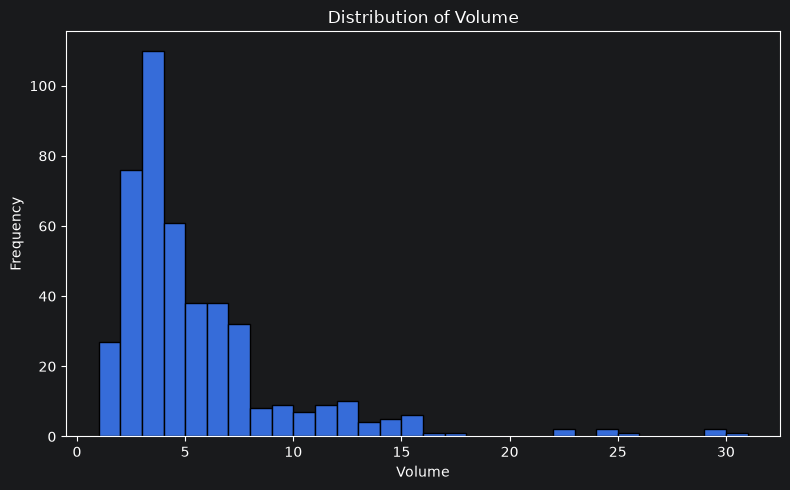

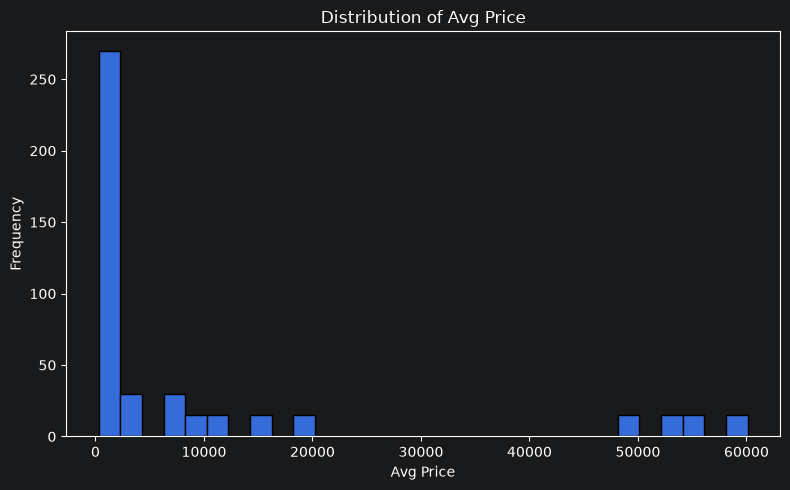

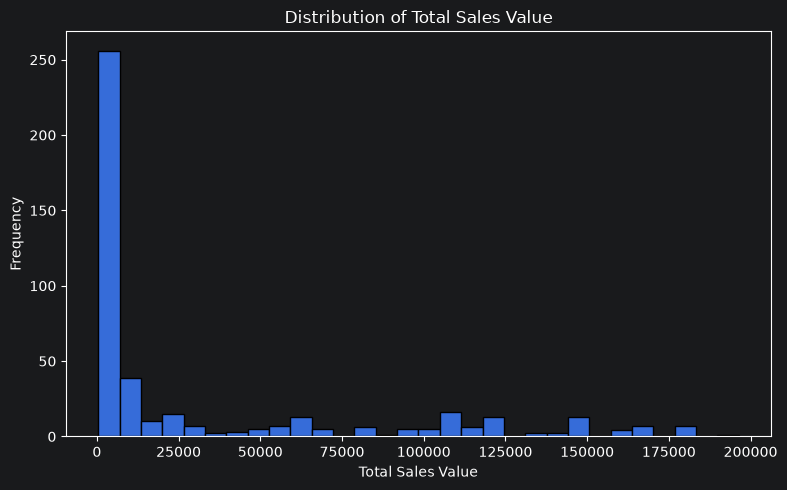

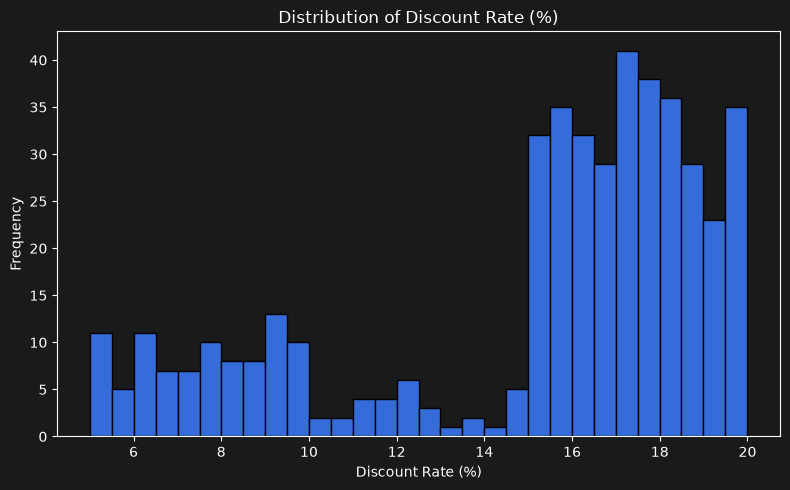

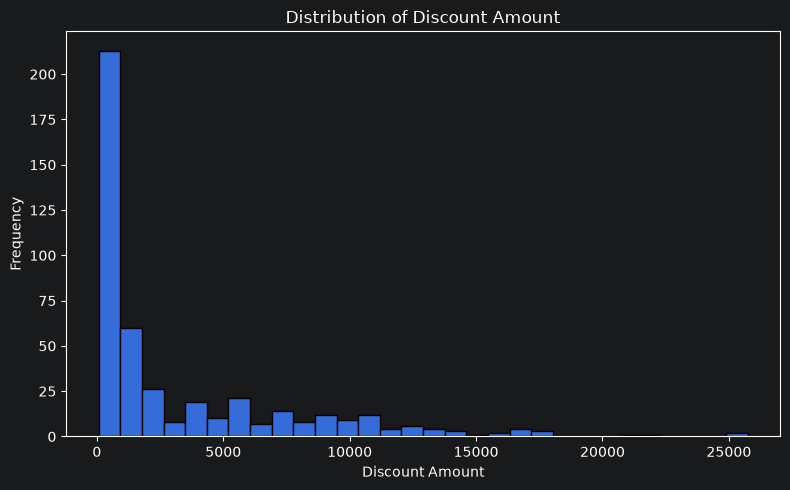

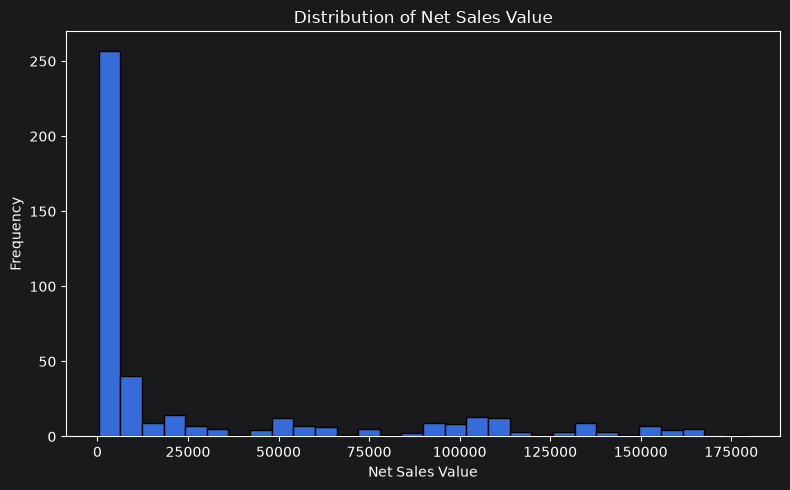

In [26]:
# Histograms of numerical variables

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=30, edgecolor="black")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

### Boxplots

Boxplots are used to examine the spread of numerical variables and identify potential outliers.

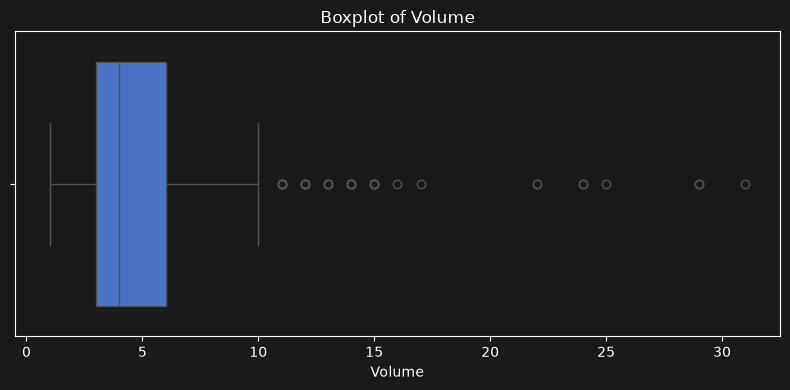

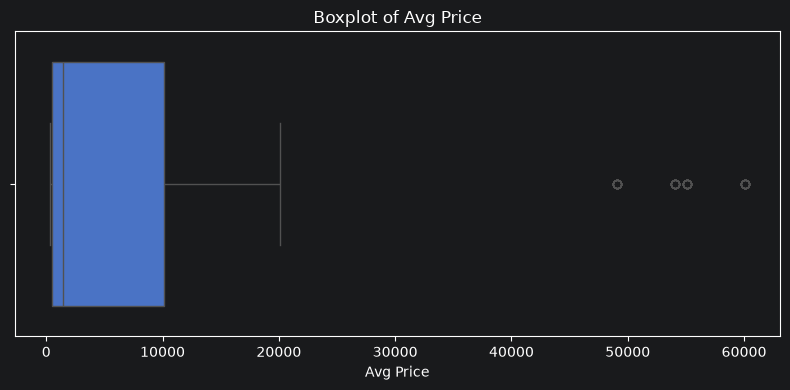

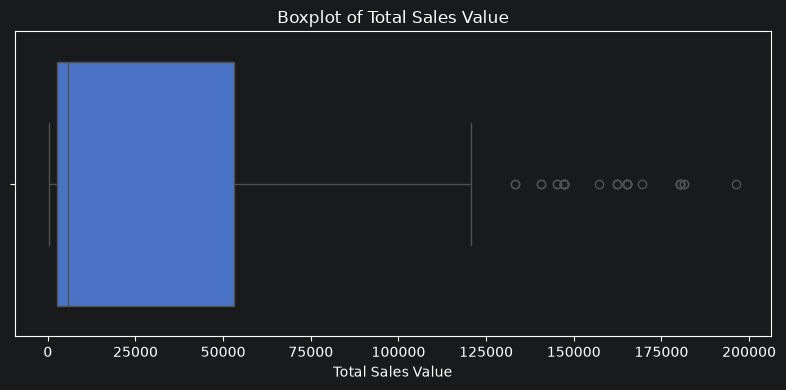

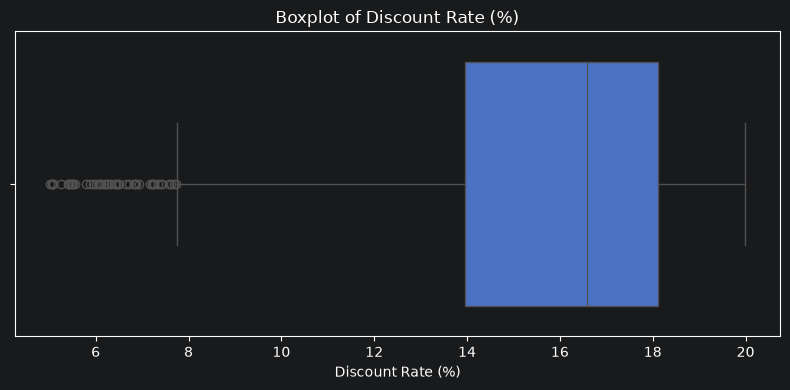

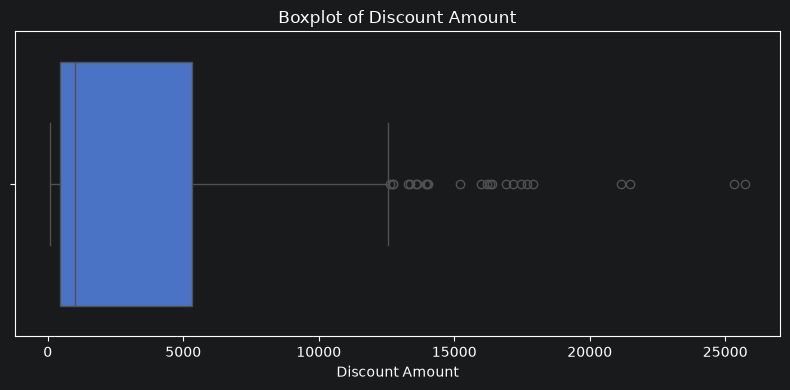

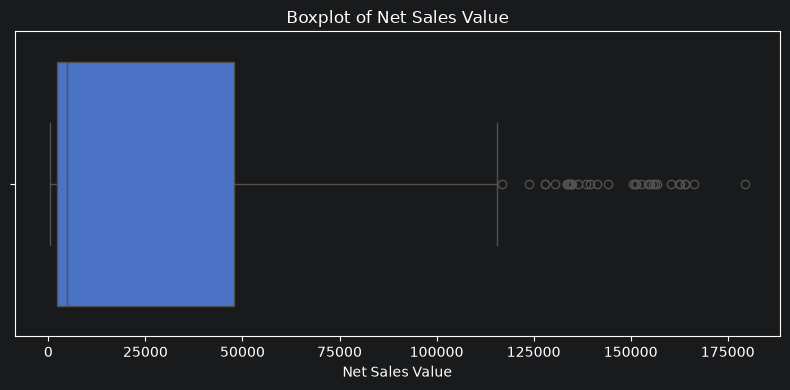

In [27]:
# Boxplots of numerical variables

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.xlabel(column)
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

### Bar Chart

A bar chart is used to compare the total Net Sales Value across different Business Units.

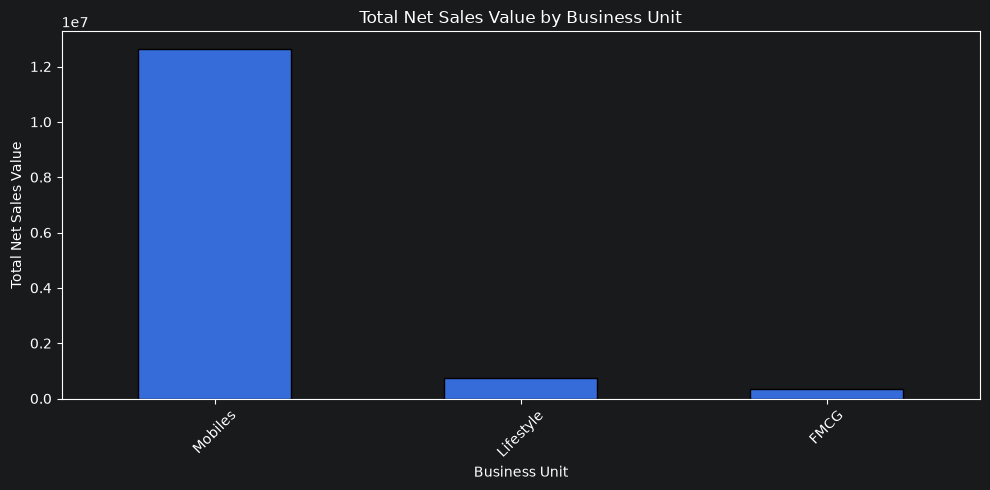

In [28]:
# Total Net Sales Value by Business Unit

bu_sales = df.groupby("BU")["Net Sales Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bu_sales.plot(kind="bar", edgecolor="black")
plt.xlabel("Business Unit")
plt.ylabel("Total Net Sales Value")
plt.title("Total Net Sales Value by Business Unit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation of Visualizations

### Histogram Interpretation

The histograms show that several numerical variables are not normally distributed. Volume, Average Price, Total Sales Value, Discount Amount, and Net Sales Value show positive/right skewness, with most observations concentrated toward the lower values and a smaller number of observations extending toward higher values. The Discount Rate (%) shows a comparatively different distribution with negative skewness.

### Boxplot Interpretation

The boxplots show the spread and presence of potential outliers in the numerical variables. Noticeable outliers are present in variables such as Volume, Average Price, Total Sales Value, Discount Amount, and Net Sales Value. These extreme observations contribute to the high standard deviation and positive skewness observed in the descriptive statistics.

### Bar Chart Interpretation

The bar chart shows a clear difference in total Net Sales Value among the Business Units. The Mobiles business unit contributes the highest total Net Sales Value by a substantial margin, followed by Lifestyle and FMCG. This indicates that the Mobiles category is the major contributor to overall net sales in this dataset.

## Business Unit Sales Comparison

The following table compares the total Net Sales Value generated by each Business Unit.

In [29]:
# Total Net Sales Value by Business Unit

bu_sales = (
    df.groupby("BU")["Net Sales Value"]
    .sum()
    .sort_values(ascending=False)
)

bu_sales.to_frame(name="Total Net Sales Value")

,Total Net Sales Value
BU,
Mobiles,12640225.50
Lifestyle,741969.61
FMCG,327656.15


## Key Insights

Based on the descriptive statistics and visualizations, the following key insights were identified:

1. The dataset contains 450 observations and 13 variables, with no missing values in any of the columns.

2. The numerical variables show considerable variation. In particular, Average Price, Total Sales Value, Discount Amount, and Net Sales Value have relatively large standard deviations and ranges.

3. Volume has a positive skewness of approximately 2.73, indicating that most observations have relatively lower volumes while a smaller number of observations have substantially higher volumes.

4. Average Price, Total Sales Value, Discount Amount, and Net Sales Value also show positive skewness. This indicates that their distributions are influenced by higher-value observations.

5. The Discount Rate (%) has negative skewness of approximately -1.06, indicating that the distribution is tilted toward higher discount-rate values.

6. The boxplots reveal several potential outliers, particularly in Volume, Average Price, Total Sales Value, Discount Amount, and Net Sales Value.

7. The histogram of Net Sales Value shows that most observations are concentrated at lower values, while a smaller number of observations extend to much higher values.

8. The Business Unit comparison shows that Mobiles generates the highest total Net Sales Value, followed by Lifestyle and FMCG.

9. Overall, the sales data contains substantial variation and several extreme observations, which should be considered when performing further statistical analysis or building predictive models.

## Conclusion

The descriptive statistical analysis provides a clear understanding of the sales dataset and its numerical variables. The dataset contains 450 observations and 13 variables, and no missing values were identified.

The analysis shows substantial variation in variables such as Average Price, Total Sales Value, Discount Amount, and Net Sales Value. Several numerical variables are positively skewed, indicating that a smaller number of high-value observations have a strong influence on the overall distribution. The boxplots also identify potential outliers across several variables.

The visualization analysis further confirms that Net Sales Value is concentrated toward lower values with a smaller number of high-value observations. The Business Unit analysis shows that Mobiles is the strongest contributor to total Net Sales Value, while Lifestyle and FMCG contribute comparatively less.

Overall, the analysis indicates that the dataset contains significant differences in sales values, discounts, prices, and volumes. The presence of skewness and potential outliers should be considered in future statistical or predictive analysis. These findings provide useful insights into the distribution of sales and the relative contribution of different Business Units.